# Simulated Annealing ABC (SABC)

## Basic tests

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from pathlib import Path
from simulated_annealing_abc import (
    sabc,
    DifferentialEvolution,
    StretchMove,
    RandomWalk,
    save_sabc_result,
    load_sabc_result,
)

In [12]:
# Path of *this* script
HERE = Path.cwd()

In [13]:
# -------------------------
# Reproducibility
# -------------------------
np.random.seed(1111)

In [20]:
# -------------------------
# True data-generating process
# -------------------------
true_mu = 3.0
true_sigma = 15.0
num_samples = 1000

y_obs = np.random.normal(true_mu, true_sigma, size=num_samples)

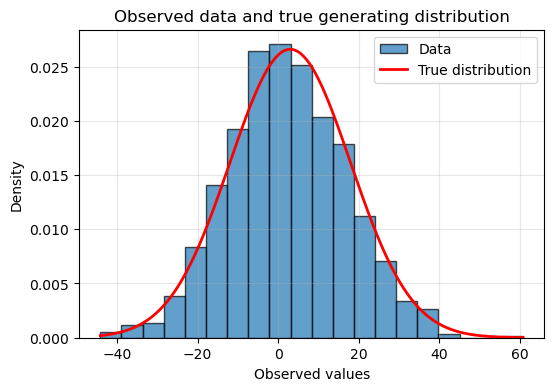

In [ ]:
# Plot the observed data and true distribution

x = np.linspace(y_obs.min(), y_obs.max(), 300)

plt.figure(figsize=(6, 4))
plt.hist(y_obs, bins=20, density=True, alpha=0.7, edgecolor="black", label="Data")
plt.plot(x, norm.pdf(x, true_mu, true_sigma), "r-", lw=2, label="True distribution")
plt.xlabel("Observed values")
plt.ylabel("Density")
plt.title("Observed data and true generating distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# -------------------------
# Prior definition
# -------------------------
mu_min, mu_max = -10.0, 20.0
sigma_min, sigma_max = 0.0, 25.0

In [23]:
# IMPORTANT -> Prior must be defined so that 
# it can generate samples (with prior.rvs) 
# and compute logpdf (with prior.logpdf)

class Prior:
    """Independent Uniform prior for (mu, sigma)."""

    def rvs(self):
        mu = np.random.uniform(mu_min, mu_max)
        sigma = np.random.uniform(sigma_min, sigma_max)
        return np.array([mu, sigma], dtype=float)

    def logpdf(self, theta):
        mu, sigma = theta
        if (mu_min <= mu <= mu_max) and (sigma_min <= sigma <= sigma_max):
            return -np.log(mu_max - mu_min) - np.log(sigma_max - sigma_min)
        return -np.inf

In [24]:
prior = Prior()

In [25]:
# -------------------------
# Summary statistics
# -------------------------
def sum_stats(data):
    stat1 = np.mean(data)
    stat2 = np.std(data, ddof=0)
    return np.array([stat1, stat2], dtype=float)

In [28]:
ss_obs = sum_stats(y_obs)
print("Observed summary statistics:", ss_obs)
n_stats = ss_obs.size
print("Number of summary statistics:", n_stats)

Observed summary statistics: [ 2.27422806 14.63570575]
Number of summary statistics: 2


In [29]:
# -------------------------
# Model + distance
# -------------------------
def model(theta):
    mu, sigma = theta
    y = np.random.normal(mu, sigma, size=num_samples)
    return sum_stats(y)

def f_dist(theta):
    ss = model(theta)
    rho = np.abs(ss - ss_obs)   # Euclidean in 1D == abs
    return rho

In [31]:
# -------------------------
# SABC parameters
# -------------------------
n_particles = 1000
n_simulation = 1_000_000
v = 1.0

In [32]:
# -------------------------
# Run: Differential Evolution
# -------------------------
out_dif = sabc(
    f_dist,
    prior,
    n_particles=n_particles,
    n_simulation=n_simulation,
    v=v,
    algorithm="single_eps",
    proposal=DifferentialEvolution(n_para=2),
)

[INFO] Initialization for 'single_eps'


Update 100/999  avg_u=0.006655  eps=[0.0012]  ETA=0:00:42
Update 200/999  avg_u=0.003982  eps=[0.0006]  ETA=0:00:36
Update 300/999  avg_u=0.002992  eps=[0.0004]  ETA=0:00:32
Update 400/999  avg_u=0.002595  eps=[0.0004]  ETA=0:00:27
Update 500/999  avg_u=0.002336  eps=[0.0003]  ETA=0:00:22
Update 600/999  avg_u=0.002141  eps=[0.0003]  ETA=0:00:18
Update 700/999  avg_u=0.001985  eps=[0.0002]  ETA=0:00:13
Update 800/999  avg_u=0.001868  eps=[0.0002]  ETA=0:00:09
Update 900/999  avg_u=0.001766  eps=[0.0002]  ETA=0:00:04


[INFO] All particles have been updated 999 times.


In [33]:
out_dif

SABCResult(population=[array([ 2.72535597, 14.74273867]), array([ 2.76931192, 15.1027104 ]), array([ 2.53903383, 14.79184593]), array([ 2.62144174, 14.60769208]), array([ 1.41623255, 14.64972109]), array([ 2.02494303, 15.06909088]), array([ 2.04548837, 14.53311297]), array([ 1.52636454, 15.19762805]), array([ 2.92678957, 15.21341255]), array([ 2.20396595, 14.04188444]), array([ 1.46770342, 14.63394125]), array([ 2.96029851, 15.30970098]), array([ 1.57363098, 14.92797218]), array([ 2.43041131, 14.7166247 ]), array([ 2.18488433, 14.46684413]), array([ 1.74079805, 15.24228234]), array([ 1.95271081, 14.45212685]), array([ 2.86255619, 14.2737673 ]), array([ 1.26954355, 14.33929106]), array([ 2.40704059, 14.58225908]), array([ 2.48716959, 14.68289484]), array([ 3.14989591, 14.19247161]), array([ 2.8297312 , 14.95733044]), array([ 3.5209109 , 14.49204882]), array([ 2.72894172, 14.8249427 ]), array([ 2.19636778, 14.66161921]), array([ 2.38756616, 14.72780217]), array([ 1.43811617, 14.03469645]

In [ ]:
save_sabc_result(out_dif, HERE / "test_results" / "out_differential_evolution.pkl")

In [ ]:
# -------------------------
# Run: Stretch Move
# -------------------------
out_str = sabc(
    f_dist,
    prior,
    n_particles=n_particles,
    n_simulation=n_simulation,
    v=v,
    algorithm="single_eps",
    proposal=StretchMove(),
)

In [ ]:
save_sabc_result(out_str, HERE / "test_results" / "out_stretch_move.pkl")

In [ ]:
# -------------------------
# Run: Random Walk
# -------------------------
out_rnd = sabc(
    f_dist,
    prior,
    n_particles=n_particles,
    n_simulation=n_simulation,
    v=v,
    algorithm="single_eps",
    proposal=RandomWalk(n_para=2),
)

In [ ]:
save_sabc_result(out_rnd, HERE / "test_results" / "out_random_walk.pkl")

In [ ]:
print("All runs completed and saved.")